[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxiRuess/DeepLearning_101/blob/main/notebooks/05_Papers/01_DPO.ipynb)

# DPO: Direct Preference Optimization

This notebook implements **DPO** (Rafailov et al., 2023), the simplest method for aligning
language models with human preferences. DPO eliminates both the reward model and online
generation — it learns directly from preference pairs using a supervised loss.

We will:
1. Understand why DPO is simpler than PPO/GRPO for alignment
2. Derive the DPO loss from the RLHF objective
3. Implement DPO from scratch on GPT-2
4. Show TRL's production `DPOTrainer`
5. Compare DPO, PPO, and GRPO

**Reference:** Rafailov, R. et al. (2023). *Direct Preference Optimization: Your Language
Model is Secretly a Reward Model.* NeurIPS 2023. https://arxiv.org/abs/2305.18290

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
import pandas as pd
from src.utils.device import set_seed

set_seed(42)
device = "cpu"

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    print("Transformers available")
except ImportError:
    print("transformers not installed")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

Set seed for reproducibility: 42


/Users/maximilianruess/Documents/GitHub/DeepLearning_101/dl_101/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transformers available
PyTorch version: 2.11.0
Device: cpu


## 1. The Alignment Pipeline

The standard RLHF pipeline has 3 steps:
1. **SFT** — supervised fine-tuning on instruction data
2. **Reward Model** — train a model to predict human preferences
3. **RL** — optimize the policy against the reward model (PPO or GRPO)

DPO **collapses steps 2 and 3 into one**. No reward model, no online generation.

| | PPO | GRPO | **DPO** |
|---|---|---|---|
| Reward model | Yes | No (reward function) | **No** |
| Online generation | Yes | Yes | **No** |
| Critic/value network | Yes | No | **No** |
| Training data | Prompts only | Prompts only | **Preference pairs** |
| Training type | RL (policy gradient) | RL (policy gradient) | **Supervised** |
| Complexity | High | Medium | **Low** |
| Used by | ChatGPT | DeepSeek-R1 | **LLaMA 3, Zephyr, Mistral** |

## 2. DPO's Key Insight

The RLHF objective maximizes reward while staying close to the reference model:

$\max_{\pi_\theta} \mathbb{E}[r(x, y)] - \beta \cdot D_{KL}(\pi_\theta \| \pi_{ref})$

The key insight: the **optimal policy** for this objective has a closed-form solution:

$\pi^*(y|x) = \frac{1}{Z(x)} \pi_{ref}(y|x) \exp\left(\frac{r(x,y)}{\beta}\right)$

Rearranging, the **implicit reward** of any policy is:

$r(x, y) = \beta \log \frac{\pi_\theta(y|x)}{\pi_{ref}(y|x)} + \beta \log Z(x)$

This means we don't need a separate reward model — the policy itself *is* the reward
model. We can plug this into the Bradley-Terry preference model and optimize directly.

## 3. The DPO Loss

Given a preference pair $(x, y_c, y_r)$ where $y_c$ is chosen and $y_r$ is rejected:

$L_{DPO}(\theta) = -\mathbb{E} \left[ \log \sigma \left( \beta \left( \log \frac{\pi_\theta(y_c|x)}{\pi_{ref}(y_c|x)} - \log \frac{\pi_\theta(y_r|x)}{\pi_{ref}(y_r|x)} \right) \right) \right]$

**Intuition:** The loss decreases when:
- The policy assigns **higher** probability to the chosen completion (relative to reference)
- The policy assigns **lower** probability to the rejected completion (relative to reference)

The $\beta$ parameter controls how much the policy can deviate from the reference.
Higher $\beta$ = more conservative (stay close to reference).
Lower $\beta$ = more aggressive (prioritize preferences).

## 4. Preference Data

DPO needs triplets: **(prompt, chosen, rejected)**

```python
{"prompt": "What is the capital of France?",
 "chosen": "The capital of France is Paris.",
 "rejected": "France is a country in Europe with many cities."}
```

No reward function needed — the preference labels *are* the supervision signal.

Common preference datasets:
- **UltraFeedback** — GPT-4 annotations on diverse prompts
- **Anthropic HH** — helpful and harmless preference pairs
- **SHP** — Stack Exchange human preferences

In [2]:
def compute_dpo_loss(policy_chosen_logps, policy_rejected_logps,
                     ref_chosen_logps, ref_rejected_logps, beta=0.1):
    """
    DPO loss: -log σ(β * (π_chosen/π_ref_chosen - π_rejected/π_ref_rejected))
    """
    chosen_rewards = beta * (policy_chosen_logps - ref_chosen_logps)
    rejected_rewards = beta * (policy_rejected_logps - ref_rejected_logps)
    loss = -F.logsigmoid(chosen_rewards - rejected_rewards).mean()
    return loss, chosen_rewards.mean().item(), rejected_rewards.mean().item()


# Demo with dummy log-probs
# Case 1: Policy already prefers chosen (loss should be low)
loss1, cr1, rr1 = compute_dpo_loss(
    policy_chosen_logps=torch.tensor([-1.0]),     # high prob for chosen
    policy_rejected_logps=torch.tensor([-5.0]),   # low prob for rejected
    ref_chosen_logps=torch.tensor([-2.0]),
    ref_rejected_logps=torch.tensor([-2.0]),
    beta=0.1
)

# Case 2: Policy can't distinguish (loss should be high ≈ log(2))
loss2, cr2, rr2 = compute_dpo_loss(
    policy_chosen_logps=torch.tensor([-2.0]),
    policy_rejected_logps=torch.tensor([-2.0]),
    ref_chosen_logps=torch.tensor([-2.0]),
    ref_rejected_logps=torch.tensor([-2.0]),
    beta=0.1
)

# Case 3: Policy prefers rejected (loss should be very high)
loss3, cr3, rr3 = compute_dpo_loss(
    policy_chosen_logps=torch.tensor([-5.0]),     # low prob for chosen
    policy_rejected_logps=torch.tensor([-1.0]),   # high prob for rejected
    ref_chosen_logps=torch.tensor([-2.0]),
    ref_rejected_logps=torch.tensor([-2.0]),
    beta=0.1
)

print("DPO Loss for different scenarios:")
print(f"  Prefers chosen:   loss = {loss1.item():.4f} (should be low)")
print(f"  Can't distinguish: loss = {loss2.item():.4f} (≈ log(2) = {np.log(2):.4f})")
print(f"  Prefers rejected: loss = {loss3.item():.4f} (should be high)")

DPO Loss for different scenarios:
  Prefers chosen:   loss = 0.5130 (should be low)
  Can't distinguish: loss = 0.6931 (≈ log(2) = 0.6931)
  Prefers rejected: loss = 0.9130 (should be high)


## 5. How the Loss Works

The DPO loss is a **sigmoid** function of the reward margin (chosen - rejected):

- Large positive margin → $\sigma \approx 1$ → $-\log(1) \approx 0$ → low loss
- Zero margin → $\sigma = 0.5$ → $-\log(0.5) = \log(2) \approx 0.693$ → medium loss
- Large negative margin → $\sigma \approx 0$ → $-\log(0)$ → very high loss

$\beta$ controls the **sensitivity** — higher $\beta$ amplifies the margin, making the
loss sharper (more conservative updates).

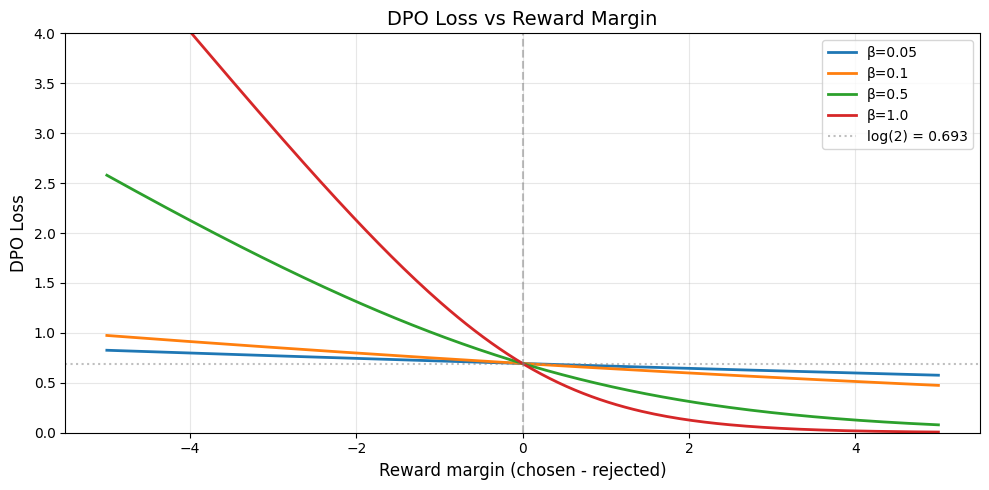

In [3]:
# Visualize DPO loss as a function of reward margin for different β
fig, ax = plt.subplots(figsize=(10, 5))

margin = np.linspace(-5, 5, 200)  # chosen_reward - rejected_reward
for beta, color in [(0.05, 'tab:blue'), (0.1, 'tab:orange'), (0.5, 'tab:green'), (1.0, 'tab:red')]:
    loss = -np.log(1 / (1 + np.exp(-beta * margin)))
    ax.plot(margin, loss, label=f'β={beta}', color=color, linewidth=2)

ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=np.log(2), color='gray', linestyle=':', alpha=0.5, label='log(2) = 0.693')
ax.set_xlabel('Reward margin (chosen - rejected)', fontsize=12)
ax.set_ylabel('DPO Loss', fontsize=12)
ax.set_title('DPO Loss vs Reward Margin', fontsize=14)
ax.set_ylim(0, 4)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
class SimpleDPOTrainer:
    """
    Educational DPO implementation on GPT-2.
    NOT production-grade — use TRL's DPOTrainer for real work.
    """

    def __init__(self, model_name="gpt2", lr=1e-5, beta=0.1):
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        self.ref_model = copy.deepcopy(self.model)
        self.ref_model.eval()
        for p in self.ref_model.parameters():
            p.requires_grad = False

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.beta = beta
        self.losses = []
        self.chosen_rewards = []
        self.rejected_rewards = []

    def get_sequence_log_probs(self, model, input_ids):
        """Get total log-prob of a token sequence."""
        outputs = model(input_ids.unsqueeze(0))
        logits = outputs.logits[0, :-1]  # shift: predict next token
        targets = input_ids[1:]           # shift: target is next token
        log_probs = F.log_softmax(logits, dim=-1)
        token_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        return token_log_probs.sum()  # total log-prob

    def train_step(self, prompt, chosen, rejected):
        """One DPO training step on a single preference pair."""
        # Tokenize
        chosen_ids = self.tokenizer.encode(prompt + chosen, return_tensors="pt")[0]
        rejected_ids = self.tokenizer.encode(prompt + rejected, return_tensors="pt")[0]

        # Policy log-probs
        self.model.train()
        policy_chosen_lp = self.get_sequence_log_probs(self.model, chosen_ids)
        policy_rejected_lp = self.get_sequence_log_probs(self.model, rejected_ids)

        # Reference log-probs
        with torch.no_grad():
            ref_chosen_lp = self.get_sequence_log_probs(self.ref_model, chosen_ids)
            ref_rejected_lp = self.get_sequence_log_probs(self.ref_model, rejected_ids)

        # DPO loss
        loss, cr, rr = compute_dpo_loss(
            policy_chosen_lp.unsqueeze(0),
            policy_rejected_lp.unsqueeze(0),
            ref_chosen_lp.unsqueeze(0),
            ref_rejected_lp.unsqueeze(0),
            beta=self.beta,
        )

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        self.losses.append(loss.item())
        self.chosen_rewards.append(cr)
        self.rejected_rewards.append(rr)
        return loss.item()


print("SimpleDPOTrainer ready.")

SimpleDPOTrainer ready.


In [5]:
# Create simple preference pairs
preference_data = [
    {
        "prompt": "What is the capital of France? ",
        "chosen": "The capital of France is Paris.",
        "rejected": "France is a country in Europe.",
    },
    {
        "prompt": "Explain photosynthesis briefly. ",
        "chosen": "Photosynthesis converts sunlight, water, and CO2 into glucose and oxygen.",
        "rejected": "Plants are green and grow in soil.",
    },
    {
        "prompt": "What is 2 + 2? ",
        "chosen": "2 + 2 = 4.",
        "rejected": "That depends on the context.",
    },
    {
        "prompt": "How do you sort a list in Python? ",
        "chosen": "Use sorted(my_list) or my_list.sort() to sort a list in Python.",
        "rejected": "Python is a programming language.",
    },
]

print(f"{len(preference_data)} preference pairs:")
for i, p in enumerate(preference_data):
    print(f"  {i+1}. {p['prompt'][:40]}...")
    print(f"     chosen:   {p['chosen'][:50]}")
    print(f"     rejected: {p['rejected'][:50]}")

4 preference pairs:
  1. What is the capital of France? ...
     chosen:   The capital of France is Paris.
     rejected: France is a country in Europe.
  2. Explain photosynthesis briefly. ...
     chosen:   Photosynthesis converts sunlight, water, and CO2 i
     rejected: Plants are green and grow in soil.
  3. What is 2 + 2? ...
     chosen:   2 + 2 = 4.
     rejected: That depends on the context.
  4. How do you sort a list in Python? ...
     chosen:   Use sorted(my_list) or my_list.sort() to sort a li
     rejected: Python is a programming language.


In [6]:
# Train DPO on GPT-2 (from scratch, runs on CPU)
print("Training DPO on GPT-2 (educational demo, CPU)...")
print("This is intentionally small-scale. Use TRL + GPU for real training.\n")

set_seed(42)
trainer = SimpleDPOTrainer(model_name="gpt2", lr=1e-5, beta=0.1)

num_epochs = 3
for epoch in range(num_epochs):
    epoch_loss = 0
    for pair in preference_data:
        loss = trainer.train_step(pair["prompt"], pair["chosen"], pair["rejected"])
        epoch_loss += loss
    avg_loss = epoch_loss / len(preference_data)
    print(f"Epoch {epoch+1}/{num_epochs} | Avg loss: {avg_loss:.4f} | "
          f"Chosen reward: {trainer.chosen_rewards[-1]:.4f} | "
          f"Rejected reward: {trainer.rejected_rewards[-1]:.4f}")

print("\nDone. Loss should decrease as the policy learns to prefer chosen over rejected.")

Training DPO on GPT-2 (educational demo, CPU)...
This is intentionally small-scale. Use TRL + GPU for real training.

Set seed for reproducibility: 42


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7835.66it/s]


Epoch 1/3 | Avg loss: 0.8583 | Chosen reward: -0.6199 | Rejected reward: -0.4545
Epoch 2/3 | Avg loss: 0.7227 | Chosen reward: -1.0603 | Rejected reward: -0.2100
Epoch 3/3 | Avg loss: 0.4720 | Chosen reward: -0.4486 | Rejected reward: -0.5237

Done. Loss should decrease as the policy learns to prefer chosen over rejected.


## 6. TRL: The Production Way

In practice, use [TRL](https://huggingface.co/docs/trl)'s `DPOTrainer` which handles:
- Tokenization and padding of preference pairs
- Reference model management
- Proper loss computation with length normalization
- Integration with PEFT/LoRA for efficiency
- Distributed training

```bash
pip install -e ".[llm]"  # installs trl, peft, accelerate, etc.
```

**Requires CUDA GPU.** If running locally on Mac, skip to Section 8 (Modal).

In [7]:
# TRL DPOTrainer (CUDA only)
if torch.cuda.is_available():
    from trl import DPOTrainer, DPOConfig
    from datasets import load_dataset

    model = AutoModelForCausalLM.from_pretrained("gpt2")
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    # Load a preference dataset
    dataset = load_dataset("trl-lib/ultrafeedback_binarized", split="train[:200]")

    config = DPOConfig(
        output_dir="./dpo-gpt2",
        num_train_epochs=1,
        per_device_train_batch_size=2,
        learning_rate=5e-5,
        beta=0.1,
        logging_steps=10,
        report_to="none",
    )

    dpo_trainer = DPOTrainer(
        model=model,
        args=config,
        train_dataset=dataset,
        processing_class=tokenizer,
    )

    dpo_trainer.train()
    print("TRL DPOTrainer training complete!")
else:
    print(f"Device: {device}")
    print("TRL DPOTrainer requires CUDA. Skip to Section 8 for Modal GPU.")
    print()
    print("The setup uses UltraFeedback preference dataset:")
    print("  DPOConfig(beta=0.1, lr=5e-5, per_device_train_batch_size=2)")
    print("  DPOTrainer(model, args, dataset, tokenizer)")

Device: cpu
TRL DPOTrainer requires CUDA. Skip to Section 8 for Modal GPU.

The setup uses UltraFeedback preference dataset:
  DPOConfig(beta=0.1, lr=5e-5, per_device_train_batch_size=2)
  DPOTrainer(model, args, dataset, tokenizer)


In [8]:
# Generate and compare (using our from-scratch trainer)
print("Sample completions after DPO training:\n")
trainer.model.eval()

for prompt in ["What is the capital of France? ", "What is 2 + 2? "]:
    inputs = trainer.tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output = trainer.model.generate(
            inputs["input_ids"],
            max_new_tokens=30,
            do_sample=True,
            temperature=0.7,
            pad_token_id=trainer.tokenizer.eos_token_id,
        )
    text = trainer.tokenizer.decode(output[0], skip_special_tokens=True)
    print(f"Prompt: {prompt}")
    print(f"Output: {text[len(prompt):]}")
    print()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Sample completions after DPO training:

Prompt: What is the capital of France? 
Output:  ( It's not a capital, I'm afraid).  And that's why it's not a capital.  For example,

Prompt: What is 2 + 2? 
Output:  (2 + 1 = 1)
So what is 2 + 2?  (2 + 1 = 1)
We could easily say



## 7. Run on GPU (Modal)

For real DPO training, use [Modal](https://modal.com) to run on a remote GPU.

```bash
pip install modal
modal token set
```

In [ ]:
MODAL_SCRIPT = '''
import modal

image = (
    modal.Image.debian_slim(python_version="3.11")
    .pip_install("torch", "transformers", "trl", "peft", "accelerate", "datasets", "tqdm")
)

app = modal.App("dl101-dpo")

@app.function(gpu="A100", image=image, timeout=3600)
def train_dpo_gpt2() -> dict:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from trl import DPOTrainer, DPOConfig
    from datasets import load_dataset

    print(f"GPU: {torch.cuda.get_device_name()}")

    model = AutoModelForCausalLM.from_pretrained("gpt2")
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    dataset = load_dataset("trl-lib/ultrafeedback_binarized", split="train[:500]")

    config = DPOConfig(
        output_dir="/tmp/dpo-output",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        learning_rate=5e-5,
        beta=0.1,
        logging_steps=10,
        report_to="none",
    )

    trainer = DPOTrainer(
        model=model, args=config,
        train_dataset=dataset, processing_class=tokenizer,
    )

    trainer.train()

    return {
        "gpu_name": torch.cuda.get_device_name(),
        "peak_memory_mb": torch.cuda.max_memory_allocated() / 1024**2,
        "train_loss": trainer.state.log_history[-1].get("loss", None),
    }
'''

print("Modal script defined.")
print("Save as .py and run: modal run <file>.py")

## 8. DPO vs PPO vs GRPO

| | PPO | GRPO | DPO |
|---|---|---|---|
| **Training type** | RL (online) | RL (online) | Supervised (offline) |
| **Needs reward model** | Yes | No (reward function) | **No** |
| **Needs generation** | Yes (sample from policy) | Yes (G completions) | **No** |
| **Needs critic** | Yes | No | **No** |
| **Training data** | Prompts | Prompts | Preference pairs |
| **Models in memory** | 3 (policy + ref + critic) | 2 (policy + ref) | 2 (policy + ref) |
| **Implementation** | Complex | Medium | **Simple** |
| **Sample efficiency** | Low (on-policy) | Low (on-policy) | **High** (offline, reuse data) |
| **Can improve beyond data?** | Yes (explores) | Yes (explores) | **No** (limited by preference data) |
| **Used by** | ChatGPT | DeepSeek-R1 | LLaMA 3, Zephyr |

## 9. Reusable Implementation

The DPO loss function is available in `src/models/dpo.py`:

```python
from src.models.dpo import compute_dpo_loss
```

In [ ]:
from src.models.dpo import compute_dpo_loss as dpo_loss

# Verify
loss, cr, rr = dpo_loss(
    torch.tensor([-1.0]), torch.tensor([-3.0]),
    torch.tensor([-2.0]), torch.tensor([-2.0]),
    beta=0.1
)
print(f"DPO loss: {loss.item():.4f}")
print(f"Chosen reward: {cr:.4f}, Rejected reward: {rr:.4f}")
print("All src/ imports verified.")

## 10. Key Takeaways

1. **DPO eliminates the reward model and online generation.** Instead of training a separate reward model and running RL, DPO learns directly from preference pairs with a supervised loss.

2. **The policy is secretly a reward model.** The DPO insight: the optimal policy under a KL-constrained reward objective has a closed form, so we can extract the implicit reward from any policy's log-probabilities.

3. **The loss is simple.** $-\log \sigma(\beta \cdot \text{margin})$ where margin = how much more the policy prefers chosen over rejected, relative to the reference. Just a sigmoid cross-entropy on log-prob ratios.

4. **$\beta$ controls conservatism.** Higher $\beta$ = stay closer to the reference model. Lower $\beta$ = optimize preferences more aggressively. Default: 0.1.

5. **DPO can't explore beyond the preference data.** Unlike PPO/GRPO which generate new completions and discover novel strategies, DPO only learns from the given preference pairs. This is both a limitation and a feature (more predictable behavior).

6. **DPO powers most open-source aligned models.** LLaMA 3, Zephyr, Mistral-Instruct, and many others use DPO or its variants (IPO, KTO) because it's simpler and often matches PPO quality.

### Variants

| Method | Key Change from DPO |
|---|---|
| IPO (Identity PO) | Replaces log-sigmoid with squared hinge — avoids overfitting |
| KTO (Kahneman-Tversky) | Works with unpaired feedback (thumbs up/down, no pairs needed) |
| ORPO | Combines SFT and preference optimization in one step |
| SimPO | Reference-free — no need for a frozen copy of the model |

### Further Reading

- Rafailov et al. (2023). *Direct Preference Optimization.* https://arxiv.org/abs/2305.18290
- Azar et al. (2023). *IPO: A General Theoretical Paradigm.* https://arxiv.org/abs/2310.12036
- Ethayarajh et al. (2024). *KTO: Model Alignment as Prospect Theoretic Optimization.* https://arxiv.org/abs/2402.01306
- TRL DPO docs: https://huggingface.co/docs/trl/dpo_trainer